In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')

In [2]:
data = pd.read_csv(r'D:\Grow Tech\Datasets\manufacturing.csv')
data

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000
...,...,...,...,...,...,...
3952,156.811578,21.794290,3417.596965,34941.963896,3.855501e+06,100.000000
3953,197.850406,8.291704,1640.516924,39714.857236,7.744742e+06,99.999997
3954,241.357144,16.391910,3956.304672,62657.690952,1.405957e+07,99.989318
3955,209.040239,23.809936,4977.234763,57195.985528,9.134036e+06,99.999975


In [3]:
data.head()

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3957 entries, 0 to 3956
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Temperature (°C)                3957 non-null   float64
 1   Pressure (kPa)                  3957 non-null   float64
 2   Temperature x Pressure          3957 non-null   float64
 3   Material Fusion Metric          3957 non-null   float64
 4   Material Transformation Metric  3957 non-null   float64
 5   Quality Rating                  3957 non-null   float64
dtypes: float64(6)
memory usage: 185.6 KB


In [6]:
data.drop_duplicates(inplace=True)
data

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric,Quality Rating
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06,99.999971
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07,99.985703
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07,99.999758
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06,99.999975
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06,100.000000
...,...,...,...,...,...,...
3952,156.811578,21.794290,3417.596965,34941.963896,3.855501e+06,100.000000
3953,197.850406,8.291704,1640.516924,39714.857236,7.744742e+06,99.999997
3954,241.357144,16.391910,3956.304672,62657.690952,1.405957e+07,99.989318
3955,209.040239,23.809936,4977.234763,57195.985528,9.134036e+06,99.999975


In [8]:
data.shape

(3957, 6)

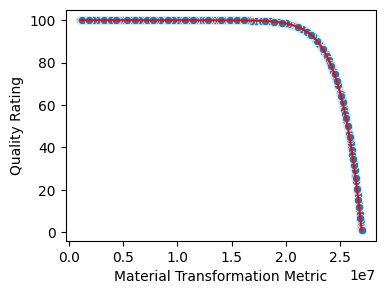

In [29]:
plt.figure(figsize=(4,3))
sns.scatterplot(x=data['Material Transformation Metric'],y=data['Quality Rating'])
sns.lineplot(x=data['Material Transformation Metric'],y=data['Quality Rating'], color = 'red')
plt.show()

In [14]:
data.columns

Index(['Temperature (°C)', 'Pressure (kPa)', 'Temperature x Pressure',
       'Material Fusion Metric', 'Material Transformation Metric',
       'Quality Rating'],
      dtype='str')

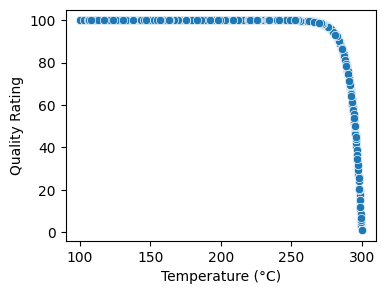

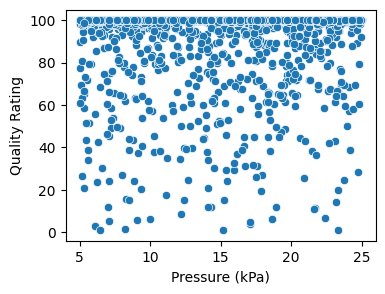

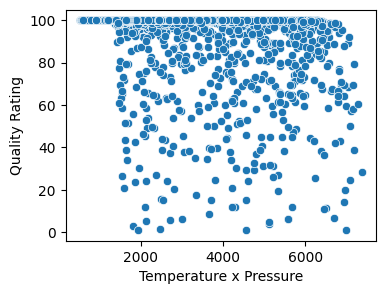

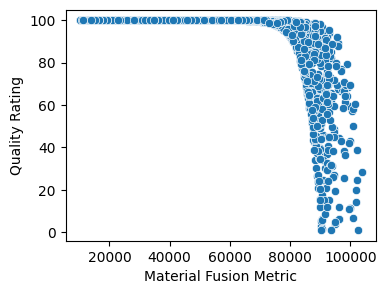

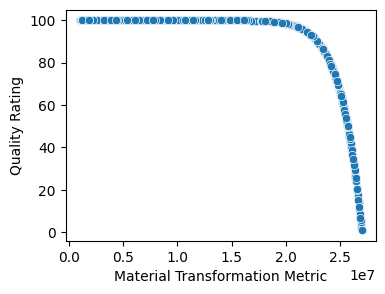

In [28]:
col = ['Temperature (°C)', 'Pressure (kPa)', 'Temperature x Pressure',
       'Material Fusion Metric', 'Material Transformation Metric']
for i in col:
       plt.figure(figsize=(4,3))
       sns.scatterplot(x=data[i],y=data['Quality Rating'])
       plt.show()

In [9]:
x1 = data[['Temperature (°C)']]
x2 = data[['Pressure (kPa)']]
x3 = data[['Material Fusion Metric']]
x4 = data[['Material Transformation Metric']]
y = data[['Quality Rating']]

In [12]:
x1.shape,x2.shape,x3.shape,x4.shape

((3957, 1), (3957, 1), (3957, 1), (3957, 1))

In [34]:
x = data.iloc[:,:-1]
y = data.iloc[:,-1]

In [35]:
x

,Temperature (°C),Pressure (kPa),Temperature x Pressure,Material Fusion Metric,Material Transformation Metric
0,209.762701,8.050855,1688.769167,44522.217074,9.229576e+06
1,243.037873,15.812068,3842.931469,63020.764997,1.435537e+07
2,220.552675,7.843130,1729.823314,49125.950249,1.072839e+07
3,208.976637,23.786089,4970.736918,57128.881547,9.125702e+06
4,184.730960,15.797812,2918.345014,38068.201283,6.303792e+06
...,...,...,...,...,...
3952,156.811578,21.794290,3417.596965,34941.963896,3.855501e+06
3953,197.850406,8.291704,1640.516924,39714.857236,7.744742e+06
3954,241.357144,16.391910,3956.304672,62657.690952,1.405957e+07
3955,209.040239,23.809936,4977.234763,57195.985528,9.134036e+06


In [36]:
y

0        99.999971
1        99.985703
2        99.999758
3        99.999975
4       100.000000
           ...    
3952    100.000000
3953     99.999997
3954     99.989318
3955     99.999975
3956    100.000000
Name: Quality Rating, Length: 3957, dtype: float64

In [42]:
X_train,X_test,y_train,y_test= train_test_split(x,y,test_size=0.3)

In [43]:
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(2769, 5) (2769,)
(1188, 5) (1188,)


In [44]:
multi_lin_model = LinearRegression()
multi_lin_model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [45]:
multi_pred = multi_lin_model.predict(X_test)
multi_pred[:10]

array([100.69070436, 102.29000476, 100.57833003, 103.55336042,
       101.89526797, 105.31601141,  92.76408552,  97.15993447,
        72.87476651,  87.37298454])

In [46]:
y_test[:10]

1723    100.000000
246      99.999943
2601     99.999252
236     100.000000
1425    100.000000
3146    100.000000
2653    100.000000
1752     99.990503
3597     65.195231
2311     99.303589
Name: Quality Rating, dtype: float64

In [48]:
from sklearn.metrics import r2_score
r2_score(y_test,multi_pred)*100

48.983463417708265

In [ ]:
# Polynomial regression
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures()
x_poly = poly_features.fit_transform(x)
x_poly[:5]

array([[1.00000000e+00, 2.09762701e+02, 8.05085537e+00, 1.68876917e+03,
        4.45222171e+04, 9.22957596e+06, 4.40003906e+04, 1.68876917e+03,
        3.54240781e+05, 9.33910050e+06, 1.93602078e+09, 6.48162722e+01,
        1.35960363e+04, 3.58441931e+05, 7.43059812e+07, 2.85194130e+06,
        7.51877474e+07, 1.55866233e+10, 1.98222781e+09, 4.10921184e+11,
        8.51850724e+13],
       [1.00000000e+00, 2.43037873e+02, 1.58120684e+01, 3.84293147e+03,
        6.30207650e+04, 1.43553672e+07, 5.90674078e+04, 3.84293147e+03,
        9.33977891e+05, 1.53164327e+07, 3.48889790e+09, 2.50021506e+02,
        6.07646951e+04, 9.96488645e+05, 2.26988047e+08, 1.47681223e+07,
        2.42184481e+08, 5.51666922e+10, 3.97161682e+09, 9.04686220e+11,
        2.06076566e+14],
       [1.00000000e+00, 2.20552675e+02, 7.84313005e+00, 1.72982331e+03,
        4.91259502e+04, 1.07283887e+07, 4.86434825e+04, 1.72982331e+03,
        3.81517159e+05, 1.08348597e+07, 2.36617483e+09, 6.15146889e+01,
        1.3567

In [52]:
x_poly.shape

(3957, 21)

In [53]:
X_train,X_test,y_train,y_test =train_test_split(x_poly,y,test_size=0.3)

In [54]:
print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)

(2769, 21) (2769,)
(1188, 21) (1188,)


In [55]:
poly_model = LinearRegression()
poly_model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
poly_pred = poly_model.predict(X_test)
poly_pred

array([101.742092  ,  97.01976687, 103.66875914, ..., 104.12399383,
       100.01635483,  91.41902295], shape=(1188,))

In [57]:
y_test

2342     99.999431
2761     99.999828
1739    100.000000
2563    100.000000
3666    100.000000
           ...    
1535     99.984483
2159    100.000000
3364     99.977431
2230     99.999879
3842     97.195325
Name: Quality Rating, Length: 1188, dtype: float64

In [ ]:
r2_score(y_test,poly_pred)

0.8715217945492427

np.float64(99.23142530795947)